In [2]:
%pip install -q pandas numpy matplotlib seaborn openpyxl statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


**Análise de série**

Text(0, 0.5, 'Unidade de medição de vento')

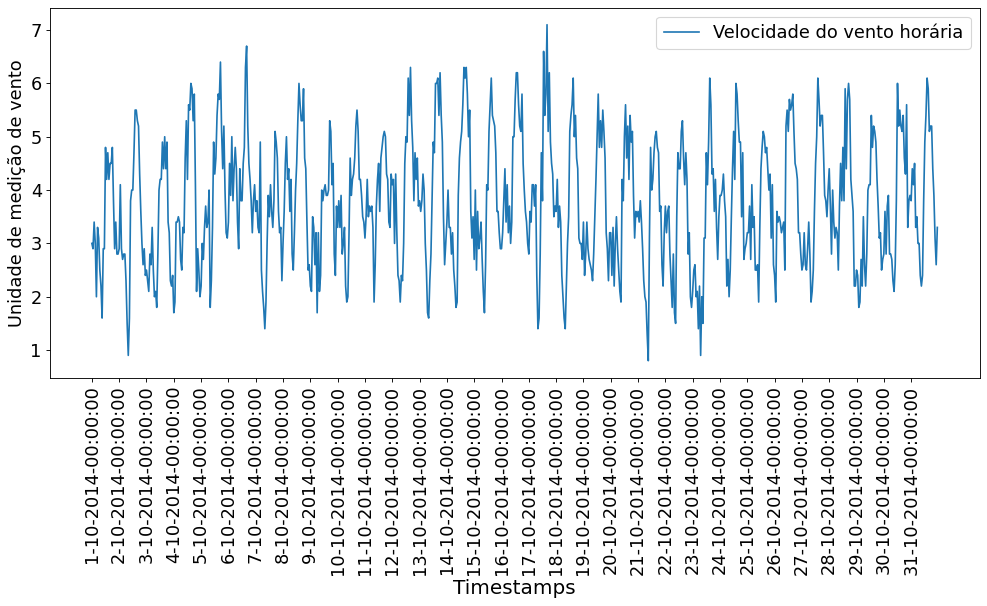

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sbn

data_horario = pd.read_excel(r'/workspaces/Series_Temporais/Data/BASEFORTALEZAhorario.xlsx')

plt.figure(figsize=(15, 6),dpi=80)
data_horario['Data'] = pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).day.map(str)+'-'+ pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).month.map(str)+'-' + pd.DatetimeIndex(data_horario['DATA (YYYY-MM-DD)']).year.map(str)+'-'+data_horario['HORA (UTC)'].map(str)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,4])
plt.legend(['Velocidade do vento horária'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de vento',fontsize=16)

In [4]:
display(data_horario)

,DATA (YYYY-MM-DD),HORA (UTC),PRECIPITACAO,TEMPERATURA,VELOCIDADE,PRESSAO,Data
0,2014-10-01,00:00:00,0.0,26.4,3.0,1011.8,1-10-2014-00:00:00
1,2014-10-01,01:00:00,0.0,26.3,2.9,1012.0,1-10-2014-01:00:00
2,2014-10-01,02:00:00,0.0,26.3,3.4,1011.5,1-10-2014-02:00:00
3,2014-10-01,03:00:00,0.0,26.4,3.0,1010.9,1-10-2014-03:00:00
4,2014-10-01,04:00:00,0.0,26.1,2.0,1010.1,1-10-2014-04:00:00
...,...,...,...,...,...,...,...
739,2014-10-31,19:00:00,0.0,29.5,4.4,1007.9,31-10-2014-19:00:00
740,2014-10-31,20:00:00,0.0,27.8,3.9,1008.2,31-10-2014-20:00:00
741,2014-10-31,21:00:00,0.0,26.7,3.1,1008.7,31-10-2014-21:00:00
742,2014-10-31,22:00:00,0.0,26.4,2.6,1009.4,31-10-2014-22:00:00


Text(0, 0.5, 'Unidade de medição de Precipitação')

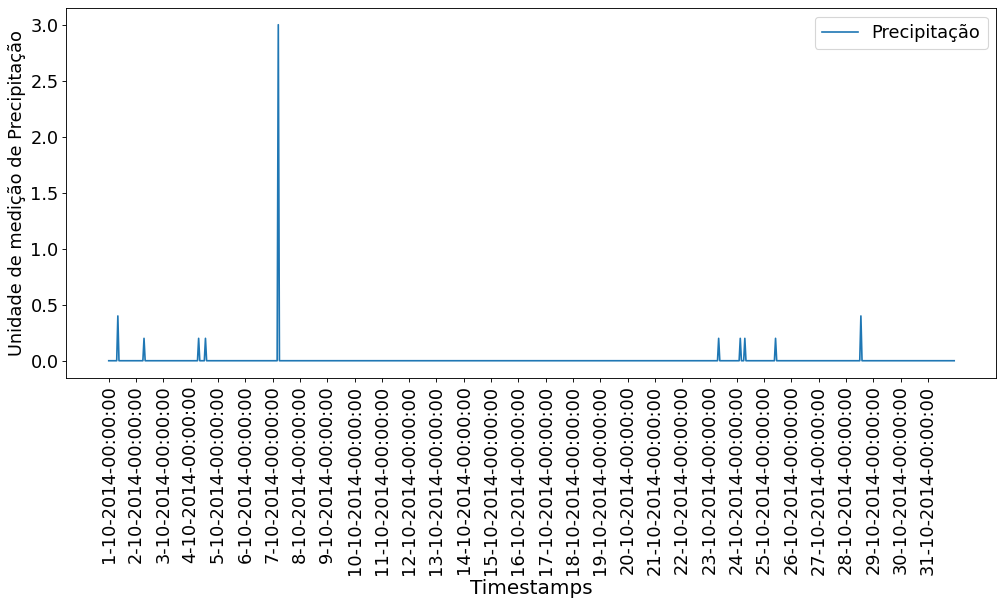

In [5]:
plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,2])
plt.legend(['Precipitação'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Precipitação',fontsize=16)

Text(0, 0.5, 'Unidade de medição de Temperatura')

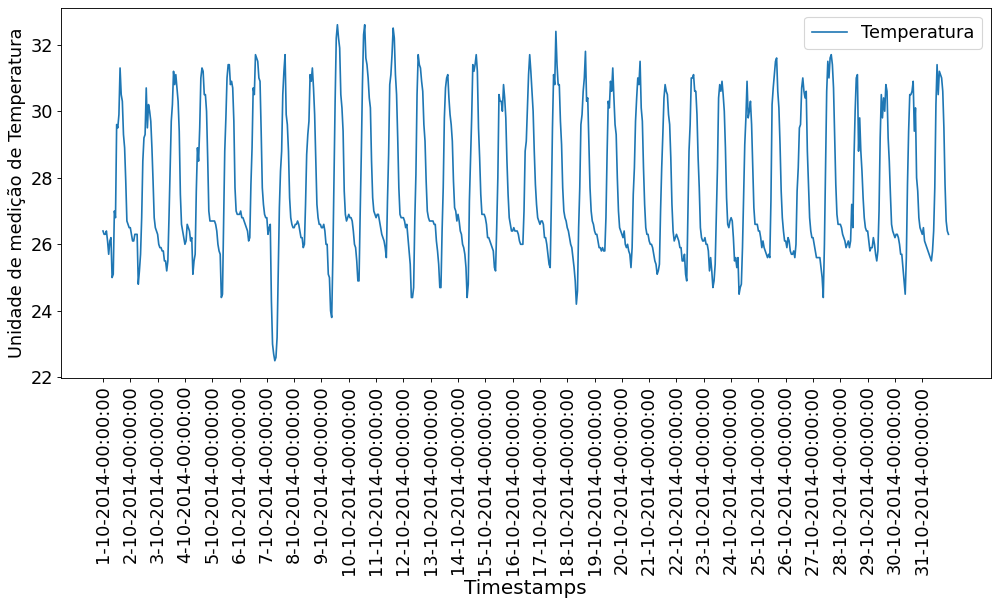

In [6]:
plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,3])
plt.legend(['Temperatura'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Temperatura',fontsize=16)

Text(0, 0.5, 'Unidade de medição de Pressão')

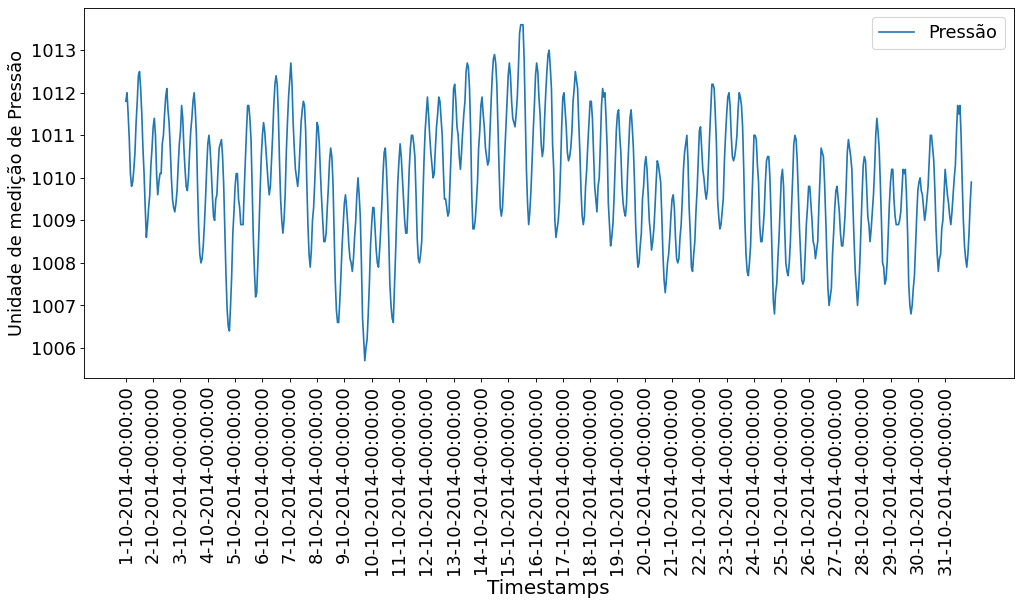

In [7]:

plt.figure(figsize=(15, 6),dpi=80)
plt.plot(data_horario.iloc[:,-1],data_horario.iloc[:,5])
plt.legend(['Pressão'],fontsize=16)
plt.xlabel('Timestamps',fontsize=18)
plt.xticks(rotation=90)
plt.xticks(np.arange(0, len(data_horario), 24),fontsize=16)
plt.yticks(fontsize=16)
plt.ylabel('Unidade de medição de Pressão',fontsize=16)

**Análise de correlação entre séries**

In [8]:
data_horario_numeric = data_horario.select_dtypes(include='number')

display(data_horario_numeric)

,PRECIPITACAO,TEMPERATURA,VELOCIDADE,PRESSAO
0,0.0,26.4,3.0,1011.8
1,0.0,26.3,2.9,1012.0
2,0.0,26.3,3.4,1011.5
3,0.0,26.4,3.0,1010.9
4,0.0,26.1,2.0,1010.1
...,...,...,...,...
739,0.0,29.5,4.4,1007.9
740,0.0,27.8,3.9,1008.2
741,0.0,26.7,3.1,1008.7
742,0.0,26.4,2.6,1009.4


,PRECIPITACAO,TEMPERATURA,VELOCIDADE,PRESSAO
PRECIPITACAO,1.000000,-0.094962,-0.055610,0.015477
TEMPERATURA,-0.094962,1.000000,0.814527,-0.088524
VELOCIDADE,-0.055610,0.814527,1.000000,-0.072784
PRESSAO,0.015477,-0.088524,-0.072784,1.000000


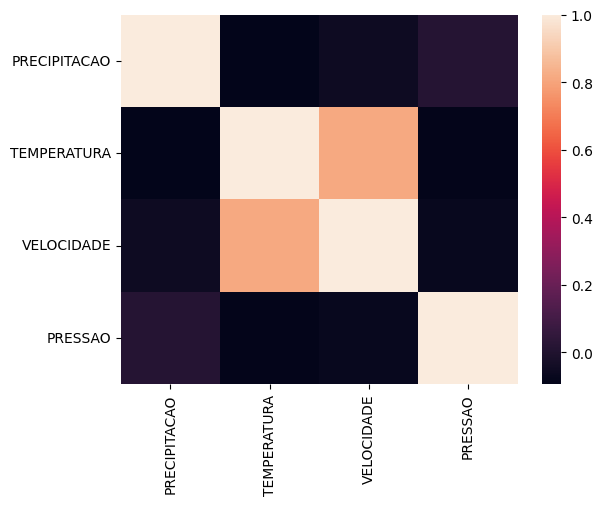

In [9]:
sbn.heatmap(data_horario_numeric.corr())
data_horario_numeric.corr()

**Decomposição de séries**

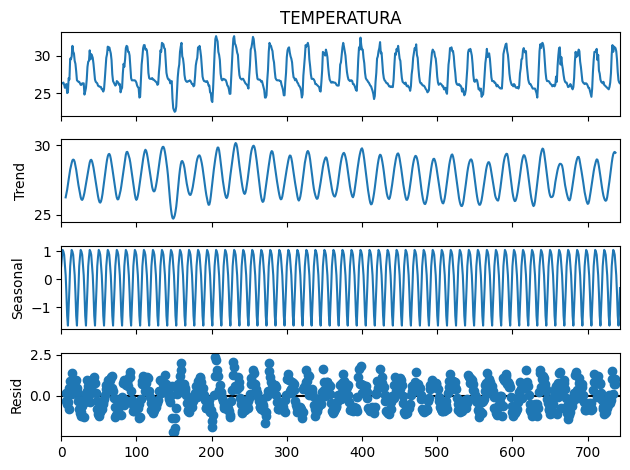

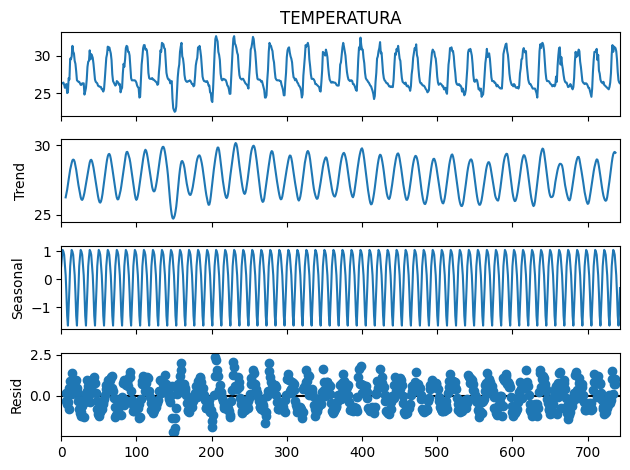

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose_result = seasonal_decompose(data_horario.iloc[:,4], model = "additive", period = 24)

decompose_result.plot()

**Análise de Distribuição**


Text(0, 0.5, 'Unidades de Velocidade do vento')

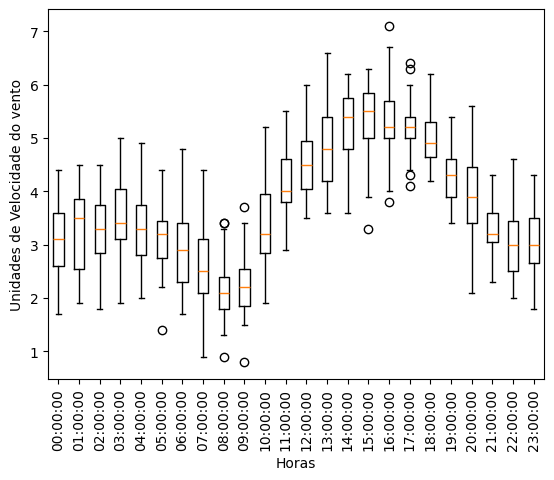

In [13]:
data_horario.iloc[:,1]
hours = np.sort(list(set(data_horario.iloc[:,1])))
speeds = []
for i in range((24)):
  speeds.append(data_horario[data_horario['HORA (UTC)']==hours[i]].iloc[:,4])
my_dc = {}
for i in range(24):
  my_dc[hours[i]]=speeds[i]

fig, ax = plt.subplots()
ax.boxplot(my_dc.values())
ax.set_xticklabels(my_dc.keys(),rotation=90)
ax.set_xlabel('Horas')
ax.set_ylabel('Unidades de Velocidade do vento')

**Exercício: Fazer a análise da base 'BASEFORTALEZAmensal.xlsx'**

**Parte 2: Análise de Autocorrelação**

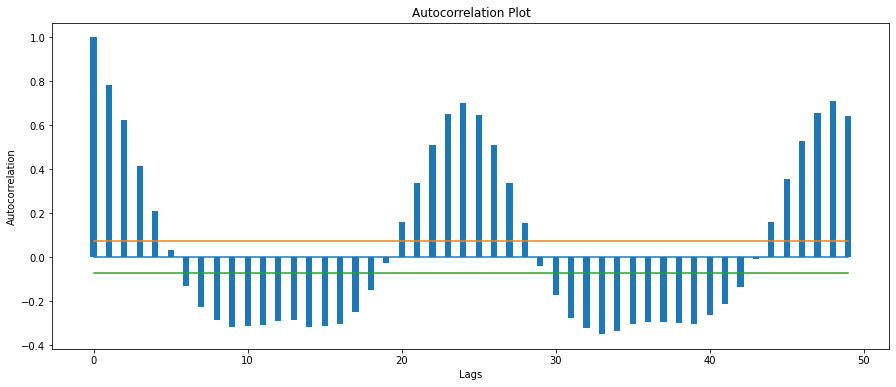

In [ ]:
def acf_plot(data,lags):
    values=[]
    for i in range((lags)):
        values.append(data.autocorr(i))
    plt.figure(figsize=(15,6))
    plt.plot(np.zeros_like(values))
    plt.plot(np.ones_like(values)*1.96*(1/np.sqrt(len(data))))
    plt.plot(np.ones_like(values)*(-1.96)*(1/np.sqrt(len(data))))
    plt.bar(range(lags),values,width=0.4)
    plt.title('Autocorrelation Plot')
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelation')
    plt.show()

acf_plot(data_horario.iloc[:,4],50)

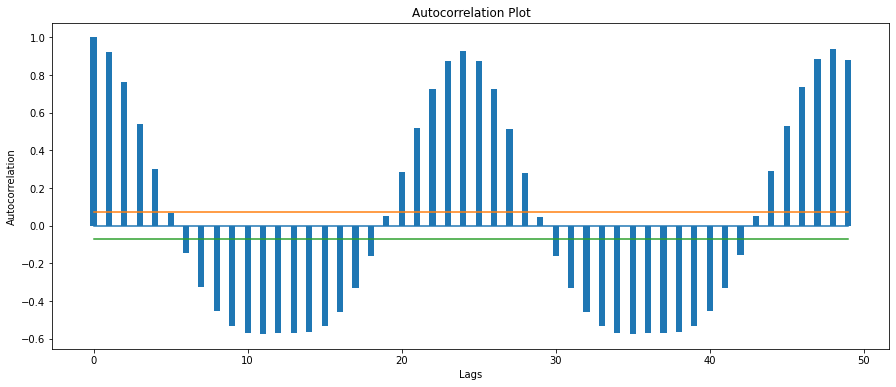

In [ ]:
acf_plot(data_horario.iloc[:,3],50)

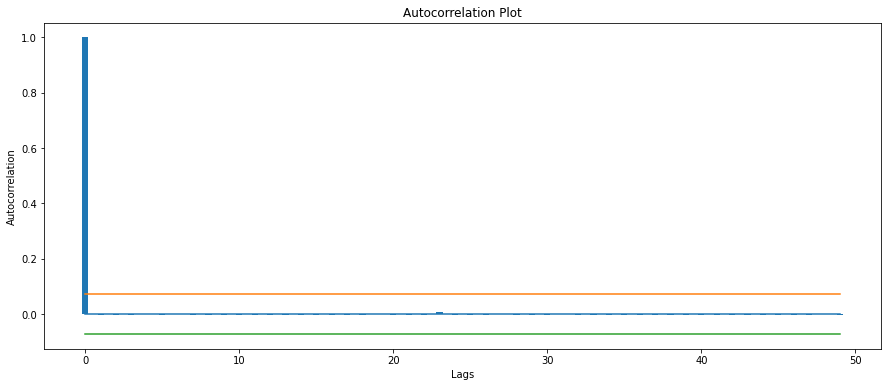

In [ ]:
acf_plot(data_horario.iloc[:,2],50)

**É possível prever os números da mega-sena?**

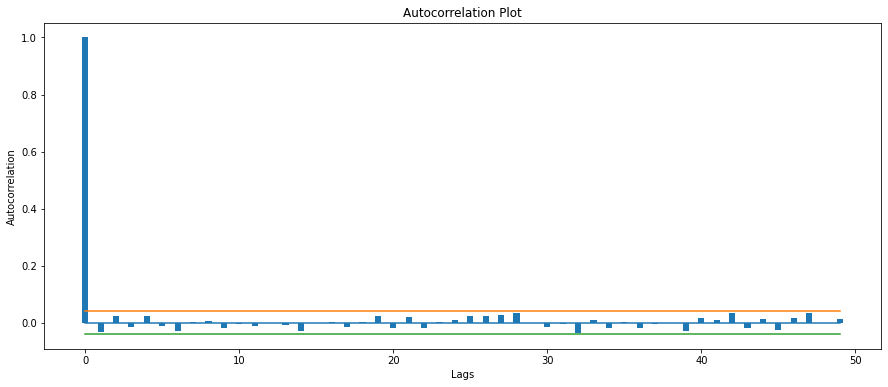

In [ ]:
import pandas as pd
data_ms= pd.read_excel('megasena.xlsx')
data_ms_inv = data_ms.iloc[::-1,:]
data_ms_inv
acf_plot(data_ms_inv.iloc[:,2],50)


Testes estatísticos para estacionariedade: **Augmented Dickey-Fuller**
Exemplo com a Temperatura

In [ ]:
from statsmodels.tsa.stattools import adfuller

res=adfuller(data_horario.iloc[:,3])
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -4.845592
p-value: 0.000044
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


Testes estatísticos para estacionariedade: Augmented Dickey-Fuller Exemplo com a Velocidade do vento

In [ ]:
res=adfuller(data_horario.iloc[:,4])
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.042920
p-value: 0.000018
Critical Values:
	1%: -3.439
	5%: -2.866
	10%: -2.569


Testes estatísticos para estacionariedade: Augmented Dickey-Fuller Exemplo com a série PM2.5

ADF Statistic: -1.733543
p-value: 0.413918
Critical Values:
	1%: -3.488
	5%: -2.887
	10%: -2.580


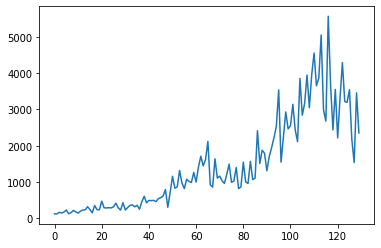

In [ ]:
data_pollution = np.loadtxt('pollutn.txt')
plt.plot(range(len(data_pollution)),data_pollution)
res=adfuller(data_pollution)
print('ADF Statistic: %f' % res[0])
print('p-value: %f' % res[1])
print('Critical Values:')
for key, value in res[4].items():
	print('\t%s: %.3f' % (key, value))
